In [641]:
## Importing all the required Libraries.

import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [642]:
### Loading Cleaned Data.
fund_master = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/01_fund_master.csv",parse_dates=["launch_date"])

nav = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/02_cleaned_nav_history.csv",parse_dates=["date"])

aum = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/03_cleaned_aum_by_fund_house.csv") 

performance = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/07_clean_scheme_performance.csv")

transactions = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/08_cleaned_investor_transaction.csv",parse_dates=["transaction_date"])

investors = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/08_cleaned_investor_transaction.csv",parse_dates=["transaction_date"])

portfolio = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/09_cleaned_portfolio_holdings.csv")

sip = pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/04_cleaned_monthly_sip_inflows.csv")

category_inflow=pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/05_cleaned_category_inflows.csv")

folio=pd.read_csv("/Users/himanshunautiyal/Desktop/untitled folder/Project/data/processed/06_clean_industry_folio_count.csv")


## Daily NAV Trend (Plotly)

In [643]:
## New data for NAV trend
nav_trend_df= pd.merge(nav,performance,on="amfi_code",how ='inner')[["amfi_code","date","nav","scheme_name","fund_house"]]
nav_trend_df.head()

,amfi_code,date,nav,scheme_name,fund_house
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


In [644]:
fig = px.line(nav_trend_df, x="date", y="nav",
    facet_col="scheme_name", facet_col_wrap=2,facet_row_spacing=0.02,
    width=1800,
    height=7000,
    title="<b>Daily NAV Trend by Scheme<b>")

fig.for_each_annotation(lambda x: x.update(text=x.text.split("=")[-1]))
fig.update_yaxes(matches=None)
fig.update_xaxes(showticklabels=True)
fig.update_layout(font={"size":14})

fig.show()

## Inference:
- Daily NAVs exhibited a strong upward  throughout the year 2023.

## AUM Growth By Fund House

In [645]:
aum["date"]=pd.to_datetime(aum["date"])
aum["year"]=aum["date"].dt.year

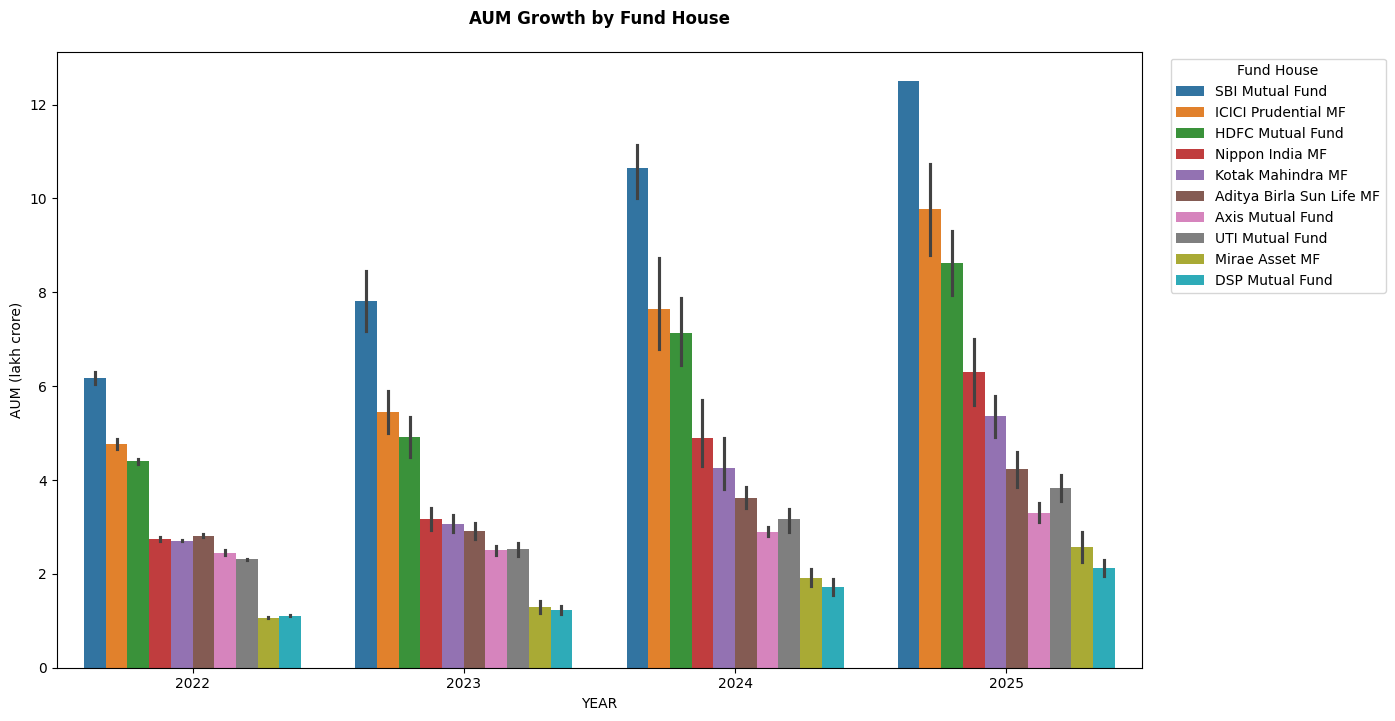

In [646]:
plt.figure(figsize=(14,8))

sns.barplot(data=aum, x="year", y="aum_lakh_crore", hue="fund_house")

plt.title("AUM Growth by Fund House",fontweight="black",pad=20)
plt.xlabel("YEAR",fontsize=10)
plt.ylabel("AUM (lakh crore)",fontsize=10)
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.show()

## Inference:
- All fund houses showed steady AUM growth, while SBI mutual funds led the market with around 12.5 lakh crore.

## SIP Monthly Trend

In [647]:
fig = px.line(sip, x="month", y="sip_inflow_crore", title="<b>Monthly SIP Inflow<b>",height=600)
fig.update_layout(xaxis_title="Month",yaxis_title="SIP Inflow(Crore)")
fig.add_annotation(x="2025-12", y=31002, text="₹31002 Cr")
fig.show()

### Inference:
- SIP inflows reached a record ₹31,002 crore in December 2025, showing that more investors were investing regularly.

## Ctegory Inflow Heatmap

In [648]:
heat=category_inflow.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)
# heat

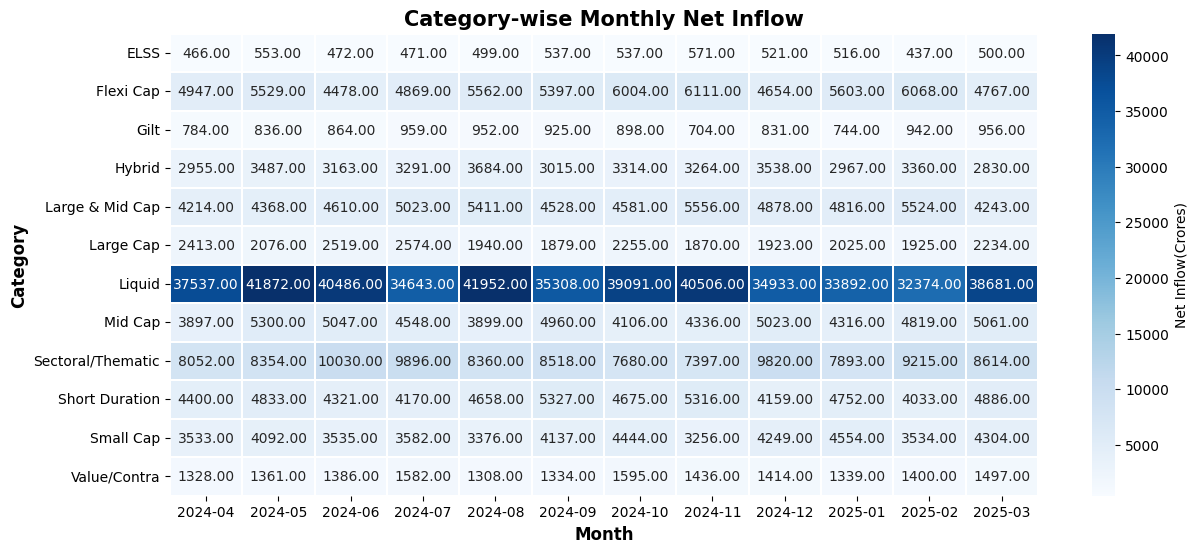

In [649]:
plt.figure(figsize=(14,6))
sns.heatmap(heat,cmap="Blues",annot=True, fmt=".2f", linewidths=0.05, linecolor="white",
            cbar_kws={"label":"Net Inflow(Crores)"}
            )

plt.title("Category-wise Monthly Net Inflow",fontsize=15,fontweight="black")
plt.xlabel("Month",fontsize=12,fontweight="black")
plt.ylabel("Category",fontsize=12,fontweight="black")

plt.show()

### Inference:
- Equity funds saw the highest inflows during strong market periods.

## Investors Demographics

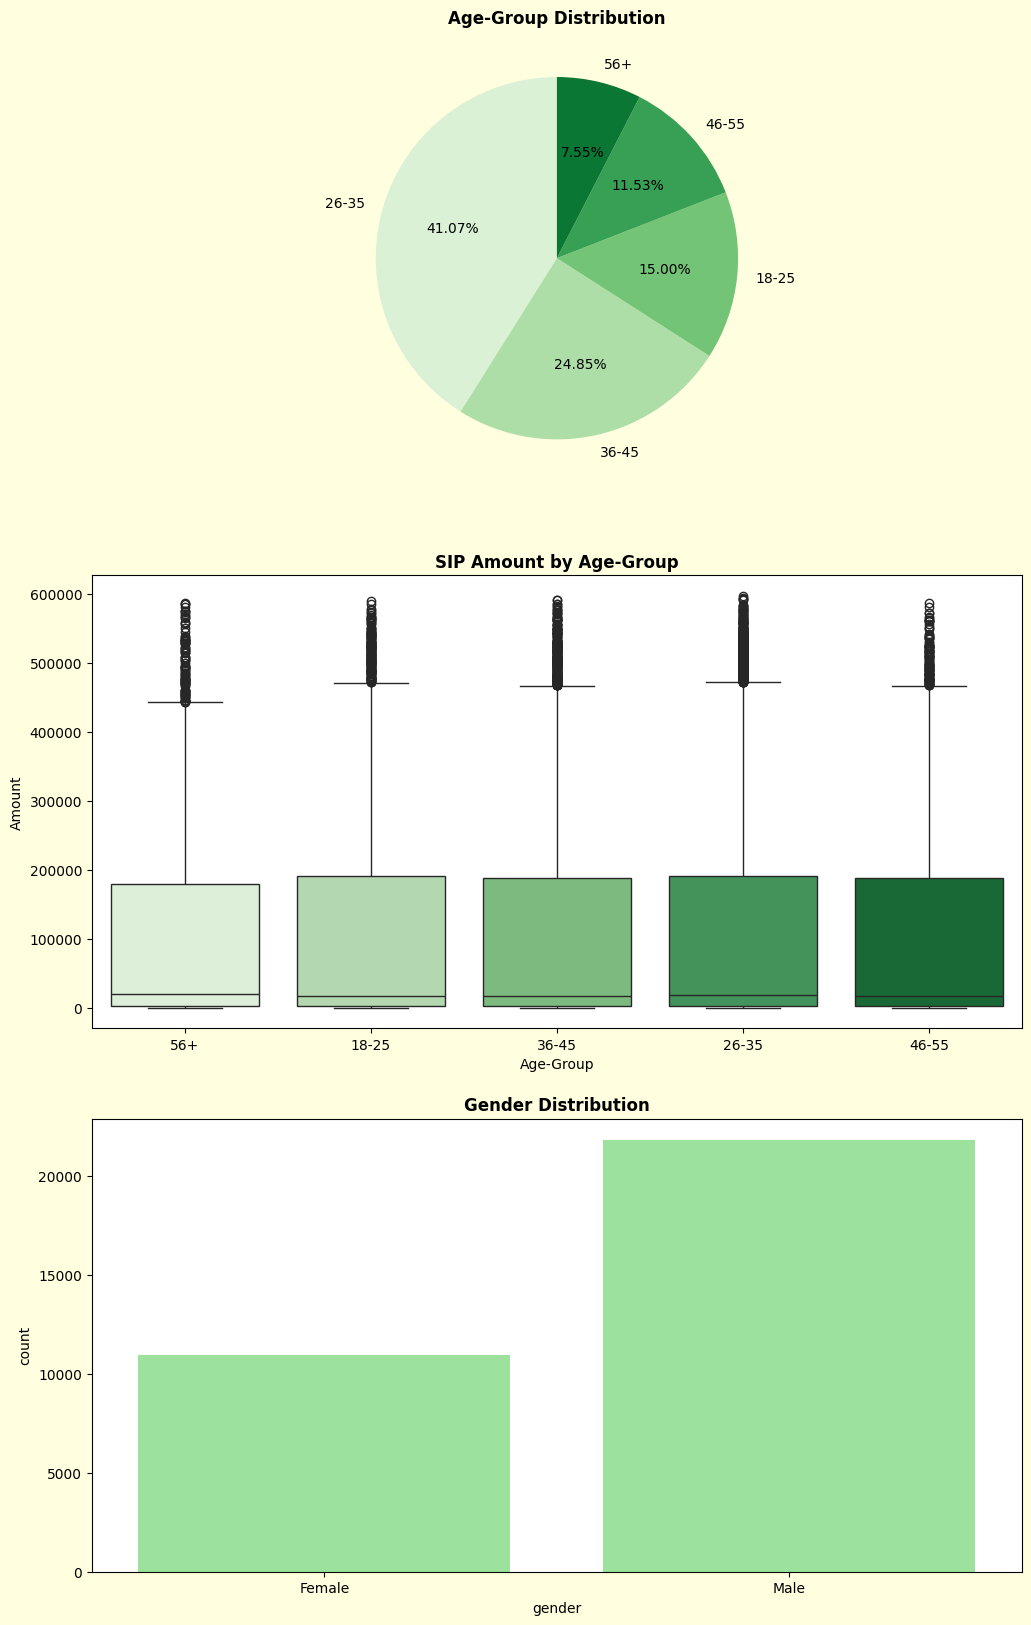

In [650]:
plt.figure(figsize=(12,20),facecolor="lightyellow")
plt.subplot(3,1,1)

pie=investors["age_group"].value_counts().to_frame().reset_index(drop=False)
plt.pie(data=pie,x="count",labels="age_group",colors=sns.color_palette("Greens",5),startangle=90,autopct="%.2f%%")
plt.title("Age-Group Distribution",fontweight="black")

plt.subplot(3,1,2)
sns.boxplot(data=investors, x="age_group",y="amount_inr",palette="Greens")
plt.title("SIP Amount by Age-Group",fontweight="black")
plt.ylabel("Amount")
plt.xlabel("Age-Group")


plt.subplot(3,1,3)
sns.countplot(data=investors,x="gender",color="lightgreen")
plt.title("Gender Distribution",fontweight="black")

plt.show()


### Inference:
- Maximum number of investors are in 26-35 age-group.
- Older investors generally invested higher SIP amounts than younger age groups, as shown by the box plot.
- Male investors represented a larger proportion of the investor base than female investors.

## Geographic Distribution

In [651]:
state= transactions.groupby(["state"])["amount_inr"].sum().sort_values().to_frame().reset_index(drop=False)
city_tier=investors["city_tier"].value_counts().to_frame().reset_index()


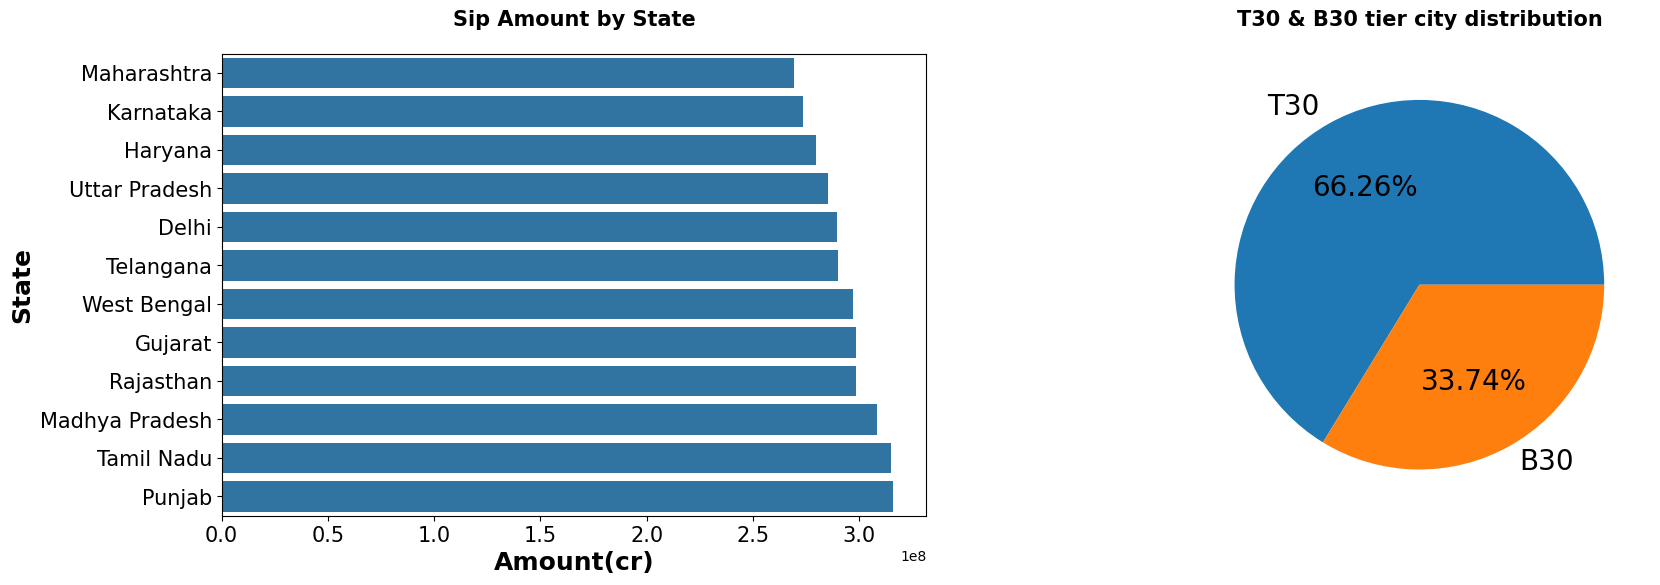

In [652]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.barplot(data=state, x="amount_inr", y="state")
plt.title("Sip Amount by State", fontsize=15,fontweight="black",pad=20)
plt.xlabel("Amount(cr)",fontweight="black",fontsize=18)
plt.ylabel("State",fontweight="black",fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.subplot(1,2,2)
plt.pie(data=city_tier,x="count",labels="city_tier",autopct="%.2f%%",textprops={"fontsize":20})
plt.xlabel("",fontsize=15)
plt.title("T30 & B30 tier city distribution" , fontsize=15, fontweight="black", pad=20)
plt.show()

### Inference:
- States with major cities mad metropolitan  cities have ehigiest SIP Investment.

## Folio Growth 

In [653]:
# folio.head()

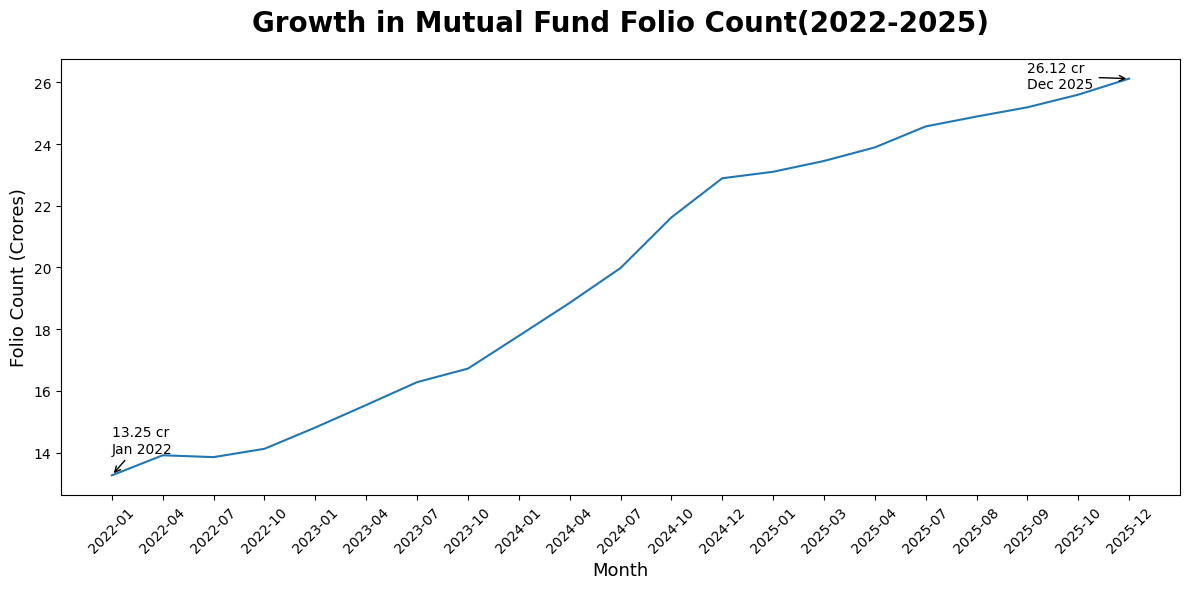

In [654]:
plt.figure(figsize=((12,6)))

sns.lineplot(data=folio, x="month", y="total_folios_crore")

plt.title("Growth in Mutual Fund Folio Count(2022-2025)",fontsize=20,fontweight="black",pad=20)
plt.xlabel("Month", fontsize=13)
plt.ylabel("Folio Count (Crores)", fontsize=13)
plt.xticks(rotation=45)

plt.annotate("13.25 cr\nJan 2022",xy=("2022-01",13.26), xytext=("2022-01",14), arrowprops={"arrowstyle":"->"})
plt.annotate("26.12 cr\nDec 2025",xy=("2025-12",26.12), xytext=("2025-09",25.8), arrowprops={"arrowstyle":"->"})

plt.tight_layout()
plt.show()

### Inference:
- Folio counts nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating rapid industry growth.

## Sector Allocation

In [ ]:
sector= portfolio.groupby(["sector"])["weight_pct"].sum()
# sector

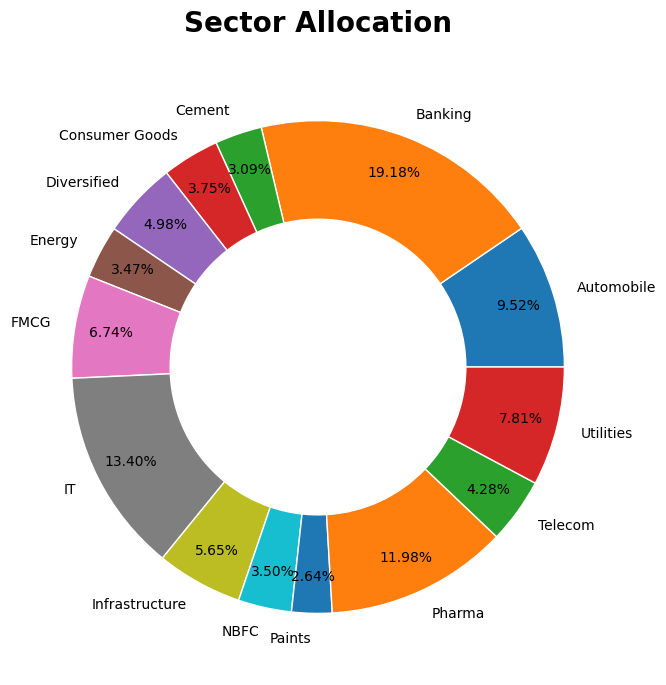

In [ ]:
plt.figure(figsize=(15,8))

plt.pie(data=sector, x=sector.values, labels=sector.index, wedgeprops={"width":0.4,"edgecolor":"white"},autopct="%.2f%%",pctdistance=0.85)
plt.title("Sector Allocation", fontsize="20", fontweight="black", pad=20)
plt.show()

## Expense Ratio Distribution

In [ ]:
performance.head()
mean=performance["expense_ratio_pct"].mean()
median=performance["expense_ratio_pct"].median()
# performance.shape

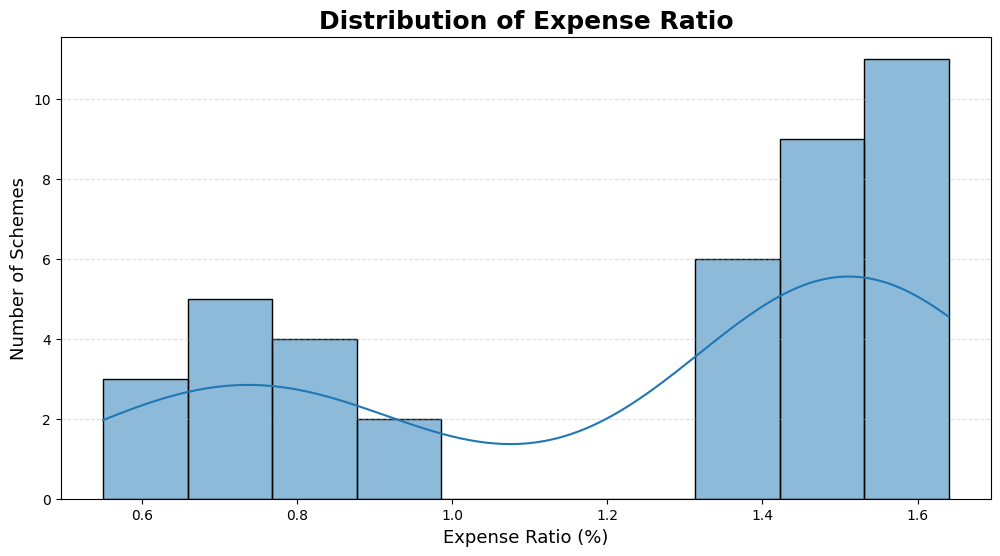

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(data=performance, x="expense_ratio_pct", bins=10, kde=True)
plt.title("Distribution of Expense Ratio", fontsize=18, fontweight="bold")
plt.xlabel("Expense Ratio (%)", fontsize=13)
plt.ylabel("Number of Schemes", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)



plt.show()

In [671]:
nav_trend_df.head()

,amfi_code,date,nav,scheme_name,fund_house,date1
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,2022-01-03
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,2022-01-04
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,2022-01-05
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,2022-01-06
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,2022-01-07


In [689]:
pivot=nav_trend_df.pivot_table(index="date", columns="fund_house", values="nav",aggfunc="mean")

corr=pivot.corr()

Text(0.5, 1.0, 'NAV Return Correlation')

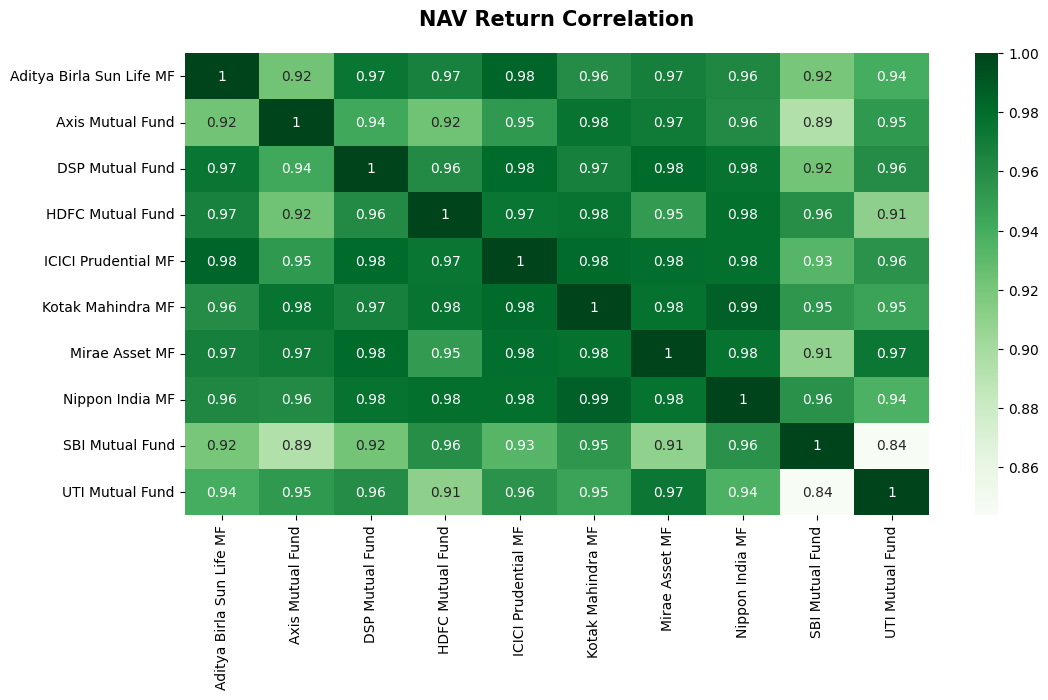

In [695]:
plt.figure(figsize=(12,6))

sns.heatmap(corr,annot=True, cmap="Greens")
plt.xlabel("")
plt.ylabel("")
plt.title("NAV Return Correlation", pad=20, fontsize=15, fontweight="black")